
# Tabular Baselines

## Objective
This notebook evaluates strong tabular baselines on the same feature set and temporal split used by the NCR model.

We compare:
- Logistic Regression
- LightGBM



In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import json
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss

import lightgbm as lgb

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/loan_project_ncr"
DATA_PATH = os.path.join(PROJECT_DIR, "monthly_df_tb3ms_borrower_seasoning.parquet")

monthly_df = pd.read_parquet(DATA_PATH)
print(monthly_df.shape)

(1656440, 38)


In [4]:
features = [
    "month_since_orig",
    "tbill_level",
    "tbill_change_3m",
    "apr_tbill_spread",
    "apr_tbill_spread_change_3m",
    "apr_tbill_spread_pct",
    "spread_x_seasoning",
    "rate_change_x_seasoning",
    "spread_pct_x_seasoning",
    "borrower_apr",
    "loan_amount_log",
    "prosper_score",
    "credit_score_lower",
    "credit_score_upper",
    "dti",
    "delinq_7y",
    "open_credit_lines",
    "revolving_balance",
    "bankcard_util",
    "available_bankcard_credit",
    "income_range",
    "employment_status",
    "homeowner",
    "prosper_score_is_missing",
    "credit_score_lower_is_missing",
    "credit_score_upper_is_missing",
    "dti_is_missing",
    "delinq_7y_is_missing",
    "open_credit_lines_is_missing",
    "revolving_balance_is_missing",
    "bankcard_util_is_missing",
    "available_bankcard_credit_is_missing",
    "income_range_is_missing",
    "employment_status_is_missing",
    "homeowner_is_missing",
]

In [5]:
def map_labels_to_order(y_raw: np.ndarray) -> np.ndarray:
    y_raw = y_raw.astype(np.int64)
    y = np.empty_like(y_raw)
    y[y_raw == 0] = 0
    y[y_raw == 2] = 1
    y[y_raw == 1] = 2
    return y


def compute_metrics_3class(y_true: np.ndarray, proba: np.ndarray) -> dict:
    pr_default = average_precision_score((y_true == 1).astype(int), proba[:, 1])
    pr_prepay = average_precision_score((y_true == 2).astype(int), proba[:, 2])
    ll = log_loss(y_true, proba, labels=[0, 1, 2])
    return {
        "log_loss": float(ll),
        "pr_auc_default": float(pr_default),
        "pr_auc_prepay": float(pr_prepay),
    }

## Temporal Split
We use the same split as in the NCR notebook to make comparisons fair.

In [7]:
train_df = monthly_df[monthly_df["cohort_year"] <= 2011].copy()
val_df = monthly_df[monthly_df["cohort_year"] == 2012].copy()
test_df = monthly_df[monthly_df["cohort_year"].isin([2013, 2014])].copy()

print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})

X_train = train_df[features].copy()
X_val = val_df[features].copy()

y_train = map_labels_to_order(train_df["status_next"].to_numpy())
y_val = map_labels_to_order(val_df["status_next"].to_numpy())

{'train': 702485, 'val': 283842, 'test': 670113}


## Preprocessing
Median imputation is fit on the training set only.

Logistic Regression also uses scaling.
LightGBM uses the imputed features directly.

In [8]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

## Logistic Regression Baseline
This serves as a simple linear multiclass baseline.

In [9]:
scaler = StandardScaler()
X_train_log = scaler.fit_transform(X_train_imp)
X_val_log = scaler.transform(X_val_imp)

log_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

log_model.fit(X_train_log, y_train)
log_val_proba = log_model.predict_proba(X_val_log)
log_val_metrics = compute_metrics_3class(y_val, log_val_proba)

print("Logistic Regression validation metrics:")
print(log_val_metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression validation metrics:
{'log_loss': 1.013647041806407, 'pr_auc_default': 0.008063896743460922, 'pr_auc_prepay': 0.012298751398038293}


## LightGBM Baseline
This is the strongest tabular baseline in the current project.

In [10]:
lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_train_imp,
    y_train,
    eval_set=[(X_val_imp, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

lgb_val_proba = lgb_model.predict_proba(X_val_imp)
lgb_val_metrics = compute_metrics_3class(y_val, lgb_val_proba)

print("LightGBM validation metrics:")
print(lgb_val_metrics)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 702485, number of used features: 32
[LightGBM] [Info] Start training from score -0.019788
[LightGBM] [Info] Start training from score -4.877154
[LightGBM] [Info] Start training from score -4.424965
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.0827389
[100]	valid_0's multi_logloss: 0.0822849
[150]	valid_0's multi_logloss: 0.0821765
[200]	valid_0's multi_logloss: 0.0821435
[250]	valid_0's multi_logloss: 0.0821298
Early stopping, best iteration is:
[228]	valid_0's multi_logloss: 0.0821233


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM validation metrics:
{'log_loss': 0.08212329389014779, 'pr_auc_default': 0.01781730169466069, 'pr_auc_prepay': 0.018177644700332465}


## Validation Summary

We compare two tabular baselines on the same feature set and temporal split used by the NCR model.

This allows us to test whether a strong tree-based model improves on a linear baseline.

In [13]:
results_df_display = results_df.copy()
results_df_display["log_loss"] = results_df_display["log_loss"].round(4)
results_df_display["pr_auc_default"] = results_df_display["pr_auc_default"].round(4)
results_df_display["pr_auc_prepay"] = results_df_display["pr_auc_prepay"].round(4)
results_df_display

,model,log_loss,pr_auc_default,pr_auc_prepay
0,LogisticRegression_3class,1.0136,0.0081,0.0123
1,LightGBM_3class,0.0821,0.0178,0.0182


## Final Validation Results

| Model | Default PR-AUC | Prepay PR-AUC |
|---|---:|---:|
| Logistic Regression | 0.0081 | 0.0123 |
| LightGBM | 0.0178 | 0.0182 |

LightGBM clearly outperforms Logistic Regression on both targets.

This suggests that nonlinear interactions between borrower characteristics, loan age, and rate features are important in this dataset.

## PR-AUC Comparison

The plot below compares the two tabular baselines directly on the validation cohort.

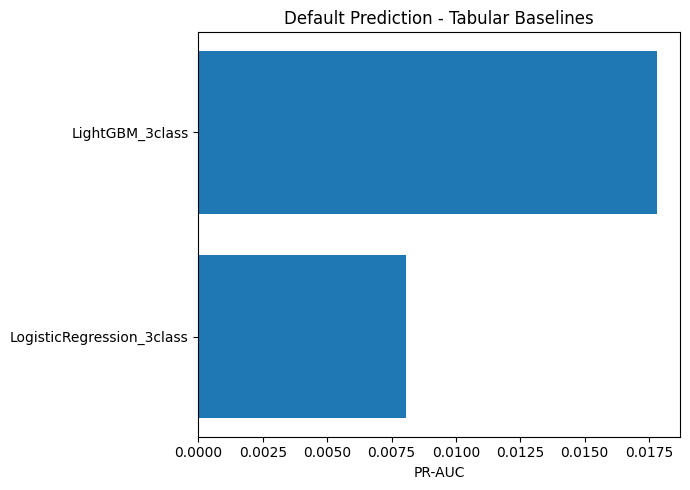

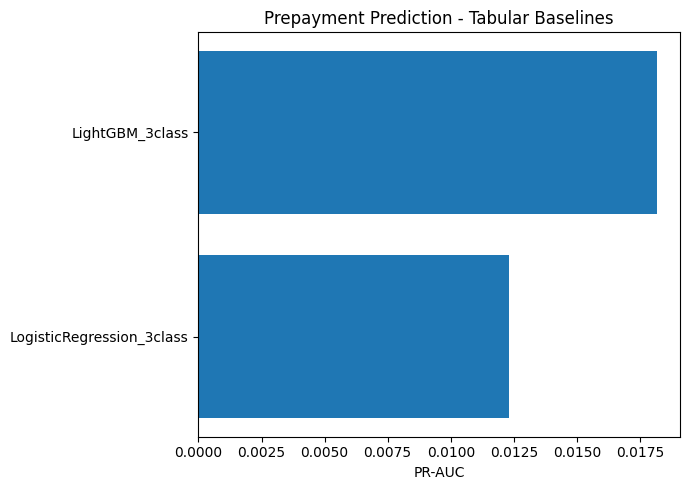

Saved: /content/drive/MyDrive/loan_project_ncr/figures/tabular_default_prauc_bar.png
Saved: /content/drive/MyDrive/loan_project_ncr/figures/tabular_prepay_prauc_bar.png


In [14]:
import os
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plot_df = results_df.copy()

# Default
df_d = plot_df.sort_values("pr_auc_default")
plt.figure(figsize=(7, 5))
plt.barh(df_d["model"], df_d["pr_auc_default"])
plt.xlabel("PR-AUC")
plt.title("Default Prediction - Tabular Baselines")
plt.tight_layout()
tab_default_path = os.path.join(FIG_DIR, "tabular_default_prauc_bar.png")
plt.savefig(tab_default_path, dpi=200, bbox_inches="tight")
plt.show()

# Prepay
df_p = plot_df.sort_values("pr_auc_prepay")
plt.figure(figsize=(7, 5))
plt.barh(df_p["model"], df_p["pr_auc_prepay"])
plt.xlabel("PR-AUC")
plt.title("Prepayment Prediction - Tabular Baselines")
plt.tight_layout()
tab_prepay_path = os.path.join(FIG_DIR, "tabular_prepay_prauc_bar.png")
plt.savefig(tab_prepay_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", tab_default_path)
print("Saved:", tab_prepay_path)

## Lift Evaluation

PR-AUC measures overall ranking quality, but it does not directly show how well the model prioritizes the highest-risk loans.

To evaluate this, we compute lift-style metrics:
- fraction of true events captured in the top 5%
- fraction of true events captured in the top 10%

This reflects how useful the model is for targeting high-risk segments.

## Ranking Performance

PR-AUC provides an overall comparison, but for portfolio applications we also want to know how many real events appear in the highest-risk segment.

To evaluate this, we compute:
- top 5% capture
- top 10% capture

In [16]:
def compute_lift(y_true, proba, event_class, top_frac=0.1):
    """
    y_true: integer labels (0=continue,1=default,2=prepay)
    proba: predicted probabilities (n_samples x 3)
    event_class: 1 for default, 2 for prepay
    top_frac: fraction of population (0.05 or 0.10)
    """

    event = (y_true == event_class).astype(int)
    score = proba[:, event_class]

    df = pd.DataFrame({
        "event": event,
        "score": score
    })

    df = df.sort_values("score", ascending=False)

    k = int(len(df) * top_frac)

    top = df.iloc[:k]

    captured = top["event"].sum()
    total = df["event"].sum()

    capture_rate = captured / total

    return {
        "top_frac": top_frac,
        "captured_events": int(captured),
        "total_events": int(total),
        "capture_rate": capture_rate
    }

In [17]:
# default lift
lift_default_5 = compute_lift(y_val, lgb_val_proba, event_class=1, top_frac=0.05)
lift_default_10 = compute_lift(y_val, lgb_val_proba, event_class=1, top_frac=0.10)

# prepay lift
lift_prepay_5 = compute_lift(y_val, lgb_val_proba, event_class=2, top_frac=0.05)
lift_prepay_10 = compute_lift(y_val, lgb_val_proba, event_class=2, top_frac=0.10)

print("LightGBM lift (validation):")
print("Default top 5%:", lift_default_5)
print("Default top 10%:", lift_default_10)

print("Prepay top 5%:", lift_prepay_5)
print("Prepay top 10%:", lift_prepay_10)

LightGBM lift (validation):
Default top 5%: {'top_frac': 0.05, 'captured_events': 296, 'total_events': 1326, 'capture_rate': np.float64(0.22322775263951736)}
Default top 10%: {'top_frac': 0.1, 'captured_events': 523, 'total_events': 1326, 'capture_rate': np.float64(0.39441930618401205)}
Prepay top 5%: {'top_frac': 0.05, 'captured_events': 282, 'total_events': 2836, 'capture_rate': np.float64(0.09943582510578279)}
Prepay top 10%: {'top_frac': 0.1, 'captured_events': 468, 'total_events': 2836, 'capture_rate': np.float64(0.16502115655853314)}


The table below summarizes LightGBM loan-month lift on the validation cohort.

In [18]:
lift_summary = pd.DataFrame([
    {"model": "LightGBM", "event": "Default", "top_5_capture": lift_default_5["capture_rate"], "top_10_capture": lift_default_10["capture_rate"]},
    {"model": "LightGBM", "event": "Prepay", "top_5_capture": lift_prepay_5["capture_rate"], "top_10_capture": lift_prepay_10["capture_rate"]},
])

lift_summary

,model,event,top_5_capture,top_10_capture
0,LightGBM,Default,0.223228,0.394419
1,LightGBM,Prepay,0.099436,0.165021


### Key Insight

LightGBM captures approximately:
- 39% of default events within the top 10% highest-risk loan-months
- 16% of prepayment events within the top 10%

This demonstrates strong ranking performance, especially for default prediction.

In [ ]:
def compute_loan_level_lift(
    df_val: pd.DataFrame,
    proba: np.ndarray,
    event_class: int,   # 1=default, 2=prepay in mapped labels
    top_frac: float = 0.10,
    agg: str = "max",   # "max" is a good first choice
):
    tmp = df_val[["loan_id", "status_next"]].copy()

    # mapped event indicator from raw status_next:
    # raw 2=default, 1=prepay
    raw_event_value = 2 if event_class == 1 else 1
    tmp["event"] = (tmp["status_next"] == raw_event_value).astype(int)
    tmp["score"] = proba[:, event_class]

    if agg == "max":
        loan_df = (
            tmp.groupby("loan_id", as_index=False)
               .agg(event=("event", "max"), score=("score", "max"))
        )
    elif agg == "mean":
        loan_df = (
            tmp.groupby("loan_id", as_index=False)
               .agg(event=("event", "max"), score=("score", "mean"))
        )
    else:
        raise ValueError("agg must be 'max' or 'mean'")

    loan_df = loan_df.sort_values("score", ascending=False)

    k = max(1, int(len(loan_df) * top_frac))
    top = loan_df.iloc[:k]

    captured = int(top["event"].sum())
    total = int(loan_df["event"].sum())
    capture_rate = captured / total if total > 0 else np.nan
    lift = capture_rate / top_frac if total > 0 else np.nan

    return {
        "n_loans": int(len(loan_df)),
        "top_frac": top_frac,
        "captured_events": captured,
        "total_events": total,
        "capture_rate": capture_rate,
        "lift": lift,
    }

# use the validation dataframe already defined in your baseline block
loan_lift_default_5 = compute_loan_level_lift(val_df, lgb_val_proba, event_class=1, top_frac=0.05)
loan_lift_default_10 = compute_loan_level_lift(val_df, lgb_val_proba, event_class=1, top_frac=0.10)

loan_lift_prepay_5 = compute_loan_level_lift(val_df, lgb_val_proba, event_class=2, top_frac=0.05)
loan_lift_prepay_10 = compute_loan_level_lift(val_df, lgb_val_proba, event_class=2, top_frac=0.10)

print("Loan-level LightGBM lift (validation):")
print("Default top 5%:", loan_lift_default_5)
print("Default top 10%:", loan_lift_default_10)
print("Prepay top 5%:", loan_lift_prepay_5)
print("Prepay top 10%:", loan_lift_prepay_10)

Loan-level LightGBM lift (validation):
Default top 5%: {'n_loans': 19244, 'top_frac': 0.05, 'captured_events': 225, 'total_events': 1326, 'capture_rate': 0.16968325791855204, 'lift': 3.3936651583710407}
Default top 10%: {'n_loans': 19244, 'top_frac': 0.1, 'captured_events': 412, 'total_events': 1326, 'capture_rate': 0.31070889894419307, 'lift': 3.1070889894419307}
Prepay top 5%: {'n_loans': 19244, 'top_frac': 0.05, 'captured_events': 268, 'total_events': 2836, 'capture_rate': 0.09449929478138223, 'lift': 1.8899858956276445}
Prepay top 10%: {'n_loans': 19244, 'top_frac': 0.1, 'captured_events': 493, 'total_events': 2836, 'capture_rate': 0.17383638928067702, 'lift': 1.7383638928067702}


## Interpretation of Results

Logistic Regression serves as a linear baseline and confirms that the feature set contains some predictive signal.

LightGBM significantly improves performance, indicating that nonlinear interactions between borrower characteristics, loan age, and interest rate dynamics are important.

In the following sections, we analyze how the model achieves this performance.

Type of shap_values: <class 'numpy.ndarray'>
shap_values.shape: (5000, 35, 3)
X_val_sample shape: (5000, 35)
shap_default shape: (5000, 35)
shap_prepay shape: (5000, 35)


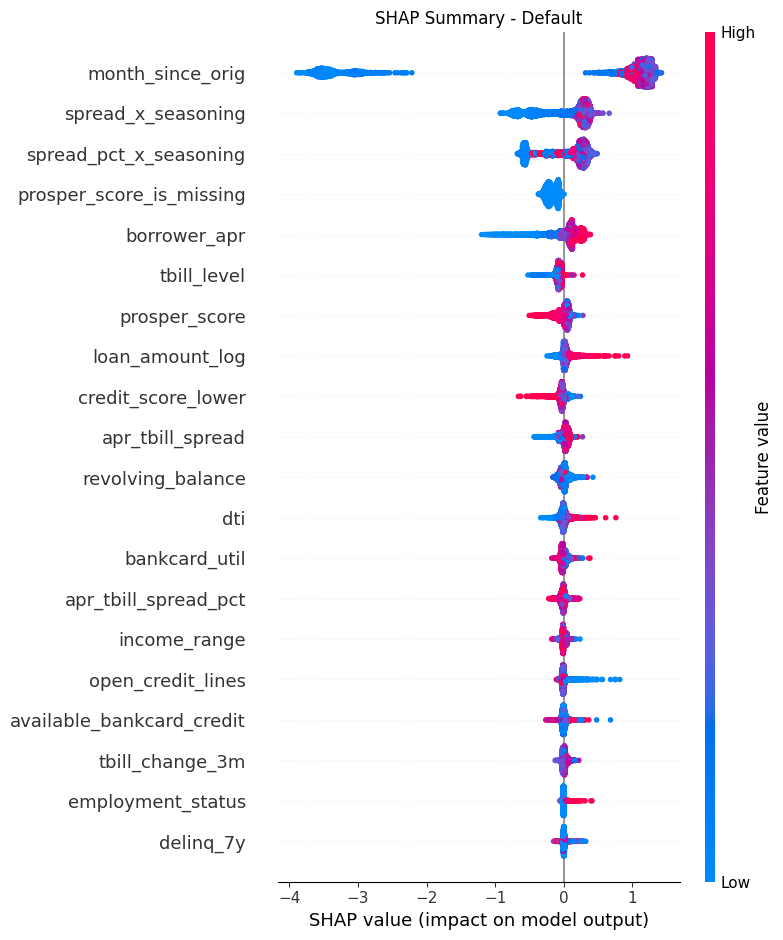

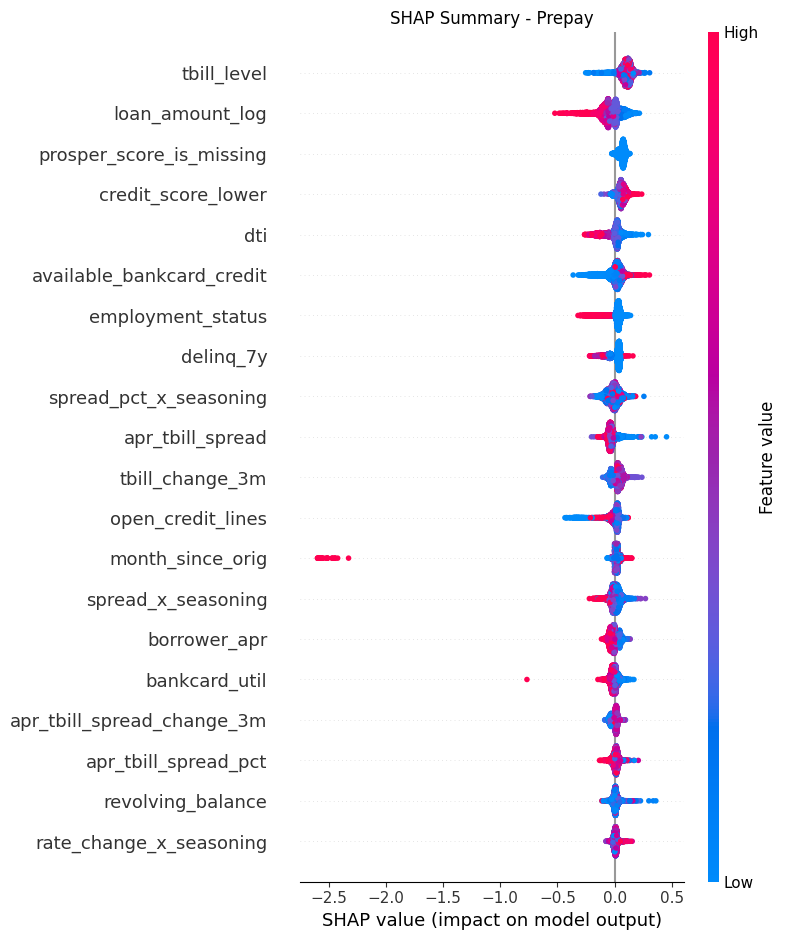

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

sample_n = 5000
rng = np.random.default_rng(42)
idx = rng.choice(X_val_imp.shape[0], size=min(sample_n, X_val_imp.shape[0]), replace=False)
X_val_sample = X_val_imp[idx]

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_val_sample)

print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("len(shap_values):", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(f"class {i} shape:", np.array(sv).shape)

    # class 1 = default, class 2 = prepay
    shap_default = np.array(shap_values[1])
    shap_prepay = np.array(shap_values[2])

elif isinstance(shap_values, np.ndarray):
    print("shap_values.shape:", shap_values.shape)

    if shap_values.ndim == 3:
        # Try to infer axis order
        if shap_values.shape[0] == X_val_sample.shape[0] and shap_values.shape[1] == X_val_sample.shape[1]:
            # (n_samples, n_features, n_classes)
            shap_default = shap_values[:, :, 1]
            shap_prepay = shap_values[:, :, 2]
        elif shap_values.shape[1] == X_val_sample.shape[0] and shap_values.shape[2] == X_val_sample.shape[1]:
            # (n_classes, n_samples, n_features)
            shap_default = shap_values[1]
            shap_prepay = shap_values[2]
        else:
            raise ValueError(f"Unexpected SHAP array shape: {shap_values.shape}")
    else:
        raise ValueError(f"Unexpected SHAP ndim: {shap_values.ndim}")
else:
    raise ValueError("Unexpected type for shap_values")

print("X_val_sample shape:", X_val_sample.shape)
print("shap_default shape:", shap_default.shape)
print("shap_prepay shape:", shap_prepay.shape)

# Convert sample back to DataFrame so feature names align cleanly
X_val_sample_df = pd.DataFrame(X_val_sample, columns=FEATURES)

# Default
shap.summary_plot(
    shap_default,
    X_val_sample_df,
    feature_names=features,
    show=False
)
plt.title("SHAP Summary - Default")
plt.tight_layout()
plt.show()

# Prepay
shap.summary_plot(
    shap_prepay,
    X_val_sample_df,
    feature_names=features,
    show=False
)
plt.title("SHAP Summary - Prepay")
plt.tight_layout()
plt.show()

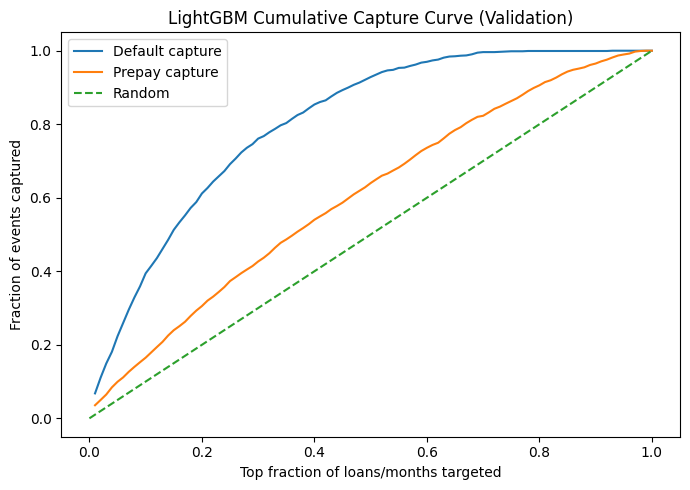

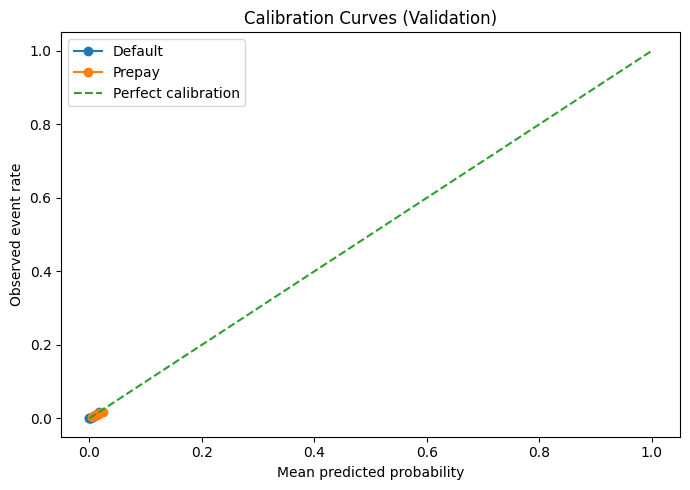

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def cumulative_capture_curve(y_true_event, scores, n_bins=100):
    df = pd.DataFrame({"y": y_true_event.astype(int), "score": scores})
    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    total_events = df["y"].sum()
    fracs = np.linspace(0.01, 1.0, n_bins)

    captures = []
    for frac in fracs:
        k = max(1, int(len(df) * frac))
        captured = df.iloc[:k]["y"].sum()
        captures.append(captured / total_events if total_events > 0 else np.nan)

    return fracs, np.array(captures)

# ----- Lift / capture curves for LightGBM -----
y_default = (y_val == 1).astype(int)
y_prepay = (y_val == 2).astype(int)

frac_d, cap_d = cumulative_capture_curve(y_default, lgb_val_proba[:, 1])
frac_p, cap_p = cumulative_capture_curve(y_prepay, lgb_val_proba[:, 2])

plt.figure(figsize=(7, 5))
plt.plot(frac_d, cap_d, label="Default capture")
plt.plot(frac_p, cap_p, label="Prepay capture")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("Top fraction of loans/months targeted")
plt.ylabel("Fraction of events captured")
plt.title("LightGBM Cumulative Capture Curve (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

# ----- Calibration curves -----
prob_true_d, prob_pred_d = calibration_curve(y_default, lgb_val_proba[:, 1], n_bins=10, strategy="quantile")
prob_true_p, prob_pred_p = calibration_curve(y_prepay, lgb_val_proba[:, 2], n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_d, prob_true_d, marker="o", label="Default")
plt.plot(prob_pred_p, prob_true_p, marker="o", label="Prepay")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration Curves (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

                      feature  importance_gain  importance_split
6          spread_x_seasoning     35613.690624              3462
8      spread_pct_x_seasoning     25315.271025              3089
0            month_since_orig     23335.660377              1479
3            apr_tbill_spread     21005.435249              2401
5        apr_tbill_spread_pct     17742.420968              2877
10            loan_amount_log     17586.114237              2916
9                borrower_apr     17199.735837              1841
14                        dti     16588.019410              3051
19  available_bankcard_credit     16521.310332              2823
17          revolving_balance     15295.231572              2687
7     rate_change_x_seasoning     15173.042489              2881
1                 tbill_level     14339.394142              1442
18              bankcard_util     13651.191763              2304
12         credit_score_lower     13056.795125              1622
16          open_credit_l

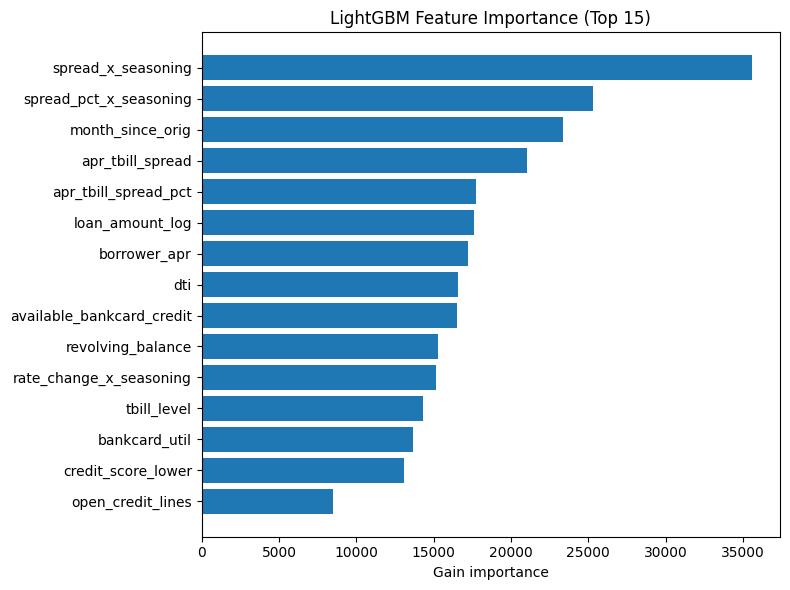

In [ ]:
gain_importance = pd.DataFrame({
    "feature": features,
    "importance_gain": lgb_model.booster_.feature_importance(importance_type="gain"),
    "importance_split": lgb_model.booster_.feature_importance(importance_type="split"),
}).sort_values("importance_gain", ascending=False)

print(gain_importance.head(15))

plt.figure(figsize=(8, 6))
topn = 15
plot_df = gain_importance.head(topn).sort_values("importance_gain", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance_gain"])
plt.xlabel("Gain importance")
plt.title("LightGBM Feature Importance (Top 15)")
plt.tight_layout()
plt.show()

## Takeaway

LightGBM is the strongest tabular baseline in the current project.

Its strongest evidence comes from:
- the highest PR-AUC among tabular models
- strong top-segment capture
- feature importance that aligns with borrower risk and rate-incentive intuition